In [173]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [174]:
from pathlib import Path

from lightning import pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint

from chemprop import data, featurizers, models, nn, utils
from chemprop.models.utils import save_model

# Loading dataset

In [175]:
# Ensure project root is on path (one level up from 'development')
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Also add the shared directory so that `utils` package can be resolved (matches streamlit_app logic)
SHARED_DIR = PROJECT_ROOT / 'shared'
print(f"Project root: {PROJECT_ROOT}")

Project root: /home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor


In [176]:
input_data_path = PROJECT_ROOT / 'data' / 'processed' / 'Tg_vs_SMILES_all.csv'

In [177]:
num_workers = 20

In [178]:
smiles_column = 'SMILES_clean'
target_column = ['logTg']

In [179]:
df_input = pd.read_csv(input_data_path)
df_input.head()

,Unnamed: 0,ID,logTg,Series,Ref,name_raw,SMILES_raw,SMI_generator,SMILES,name,SMILES_clean
0,0,PPD_007,2.7077,T,A,chloroprene,C=CC(=C)Cl,PubChemPy,C=CC(=C)Cl,chloroprene,C=CC(=C)Cl
1,1,PPD_008,2.8520,T,A,acrylamide,C=CC(=O)N,PubChemPy,C=CC(=O)N,acrylamide,C=CC(N)=O
2,2,PPD_010,2.8177,T,A,2-cyanobutyl acrylate,CCC(COC(=O)C=C)C#N,ChemAxon,CCC(COC(=O)C=C)C#N,2-cyanobutyl acrylate,C=CC(=O)OCC(C#N)CC
3,3,PPD_013,2.7178,P,A,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(C(F)F)(F)F,PubChemPy,C=CC(=O)OCC(C(F)F)(F)F,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(F)(F)C(F)F
4,4,PPD_019,2.7552,T,A,cyanomethyl acrylate,C=CC(=O)OCC#N,PubChemPy,C=CC(=O)OCC#N,cyanomethyl acrylate,C=CC(=O)OCC#N


In [180]:
df_input.shape

(902, 11)

# Adding physics-based descriptors
* Free volume proxy (using van der Waals volume)
* Chain flexibility (number of rotatable bonds)
* Aromatic content (number of aromatic rings)
* Polarity (TPSA / dipole moment proxy)
* Hydrogen bond donor/acceptor count
* Molecular weight (exact or monomer-based)


In [181]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

In [182]:
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    MW = Descriptors.MolWt(mol)
    FreeVolumeProxy = rdMolDescriptors.CalcExactMolWt(mol) / Chem.rdMolDescriptors.CalcNumHeavyAtoms(mol)  # Proxy for free volume
    RotatableBonds = Descriptors.NumRotatableBonds(mol)
    AromaticRings = Chem.rdMolDescriptors.CalcNumAromaticRings(mol)
    TPSA = Descriptors.TPSA(mol)
    HBondDonors = rdMolDescriptors.CalcNumHBD(mol)
    HBondAcceptors = rdMolDescriptors.CalcNumHBA(mol)
    return {
        'MW': MW,
        'FreeVolumeProxy': FreeVolumeProxy,
        'RotatableBonds': RotatableBonds,
        'AromaticRings': AromaticRings,
        'TPSA': TPSA,
        'HBondDonors': HBondDonors,
        'HBondAcceptors': HBondAcceptors
    }

In [183]:
descriptors_df = pd.DataFrame(list(df_input[smiles_column].apply(compute_descriptors)))

In [184]:
descriptors_df.head()

,MW,FreeVolumeProxy,RotatableBonds,AromaticRings,TPSA,HBondDonors,HBondAcceptors
0,88.537,17.601596,1,0,0.00,0,0
1,71.079,14.207423,1,0,43.09,1,1
2,153.181,13.916271,4,0,50.09,0,3
3,186.104,15.502533,4,0,26.30,0,2
4,111.100,13.879004,2,0,50.09,0,3


In [185]:
descriptors_df.shape

(902, 7)

In [186]:
n_descriptors = descriptors_df.shape[1]
n_descriptors

7

In [187]:
descriptor_list = descriptors_df.columns.tolist()
descriptor_list

['MW',
 'FreeVolumeProxy',
 'RotatableBonds',
 'AromaticRings',
 'TPSA',
 'HBondDonors',
 'HBondAcceptors']

In [188]:
df_input_w_features = pd.concat([df_input, descriptors_df], axis=1)

In [189]:
df_input_w_features.shape

(902, 18)

In [190]:
df_input_w_features.head()

,Unnamed: 0,ID,logTg,Series,Ref,name_raw,SMILES_raw,SMI_generator,SMILES,name,SMILES_clean,MW,FreeVolumeProxy,RotatableBonds,AromaticRings,TPSA,HBondDonors,HBondAcceptors
0,0,PPD_007,2.7077,T,A,chloroprene,C=CC(=C)Cl,PubChemPy,C=CC(=C)Cl,chloroprene,C=CC(=C)Cl,88.537,17.601596,1,0,0.00,0,0
1,1,PPD_008,2.8520,T,A,acrylamide,C=CC(=O)N,PubChemPy,C=CC(=O)N,acrylamide,C=CC(N)=O,71.079,14.207423,1,0,43.09,1,1
2,2,PPD_010,2.8177,T,A,2-cyanobutyl acrylate,CCC(COC(=O)C=C)C#N,ChemAxon,CCC(COC(=O)C=C)C#N,2-cyanobutyl acrylate,C=CC(=O)OCC(C#N)CC,153.181,13.916271,4,0,50.09,0,3
3,3,PPD_013,2.7178,P,A,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(C(F)F)(F)F,PubChemPy,C=CC(=O)OCC(C(F)F)(F)F,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(F)(F)C(F)F,186.104,15.502533,4,0,26.30,0,2
4,4,PPD_019,2.7552,T,A,cyanomethyl acrylate,C=CC(=O)OCC#N,PubChemPy,C=CC(=O)OCC#N,cyanomethyl acrylate,C=CC(=O)OCC#N,111.100,13.879004,2,0,50.09,0,3


In [191]:
df_input_w_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 902 entries, 0 to 901
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       902 non-null    int64  
 1   ID               902 non-null    object 
 2   logTg            902 non-null    float64
 3   Series           902 non-null    object 
 4   Ref              902 non-null    object 
 5   name_raw         902 non-null    object 
 6   SMILES_raw       902 non-null    object 
 7   SMI_generator    902 non-null    object 
 8   SMILES           902 non-null    object 
 9   name             902 non-null    object 
 10  SMILES_clean     902 non-null    object 
 11  MW               902 non-null    float64
 12  FreeVolumeProxy  902 non-null    float64
 13  RotatableBonds   902 non-null    int64  
 14  AromaticRings    902 non-null    int64  
 15  TPSA             902 non-null    float64
 16  HBondDonors      902 non-null    int64  
 17  HBondAcceptors  

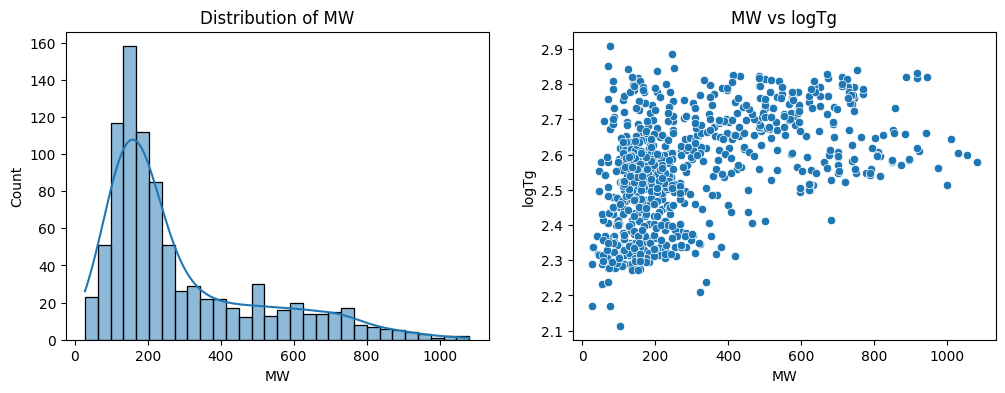

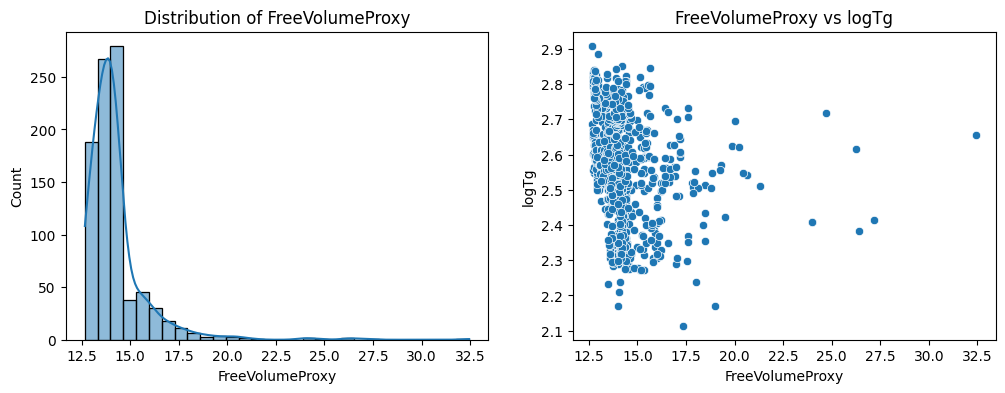

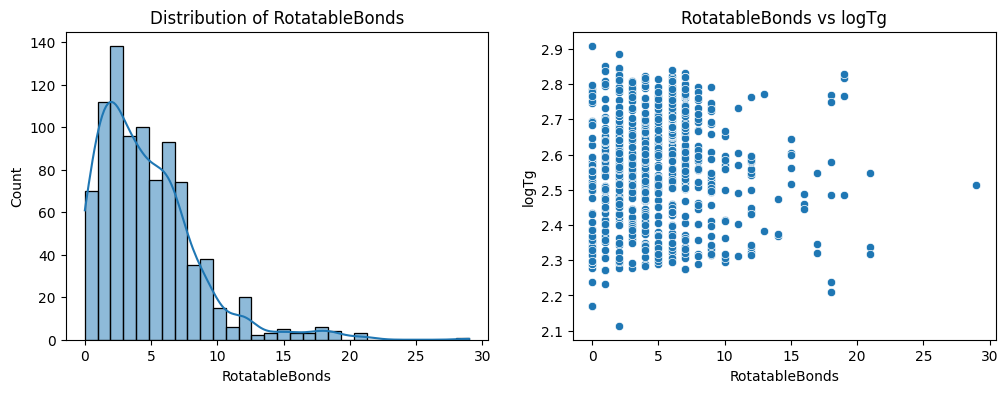

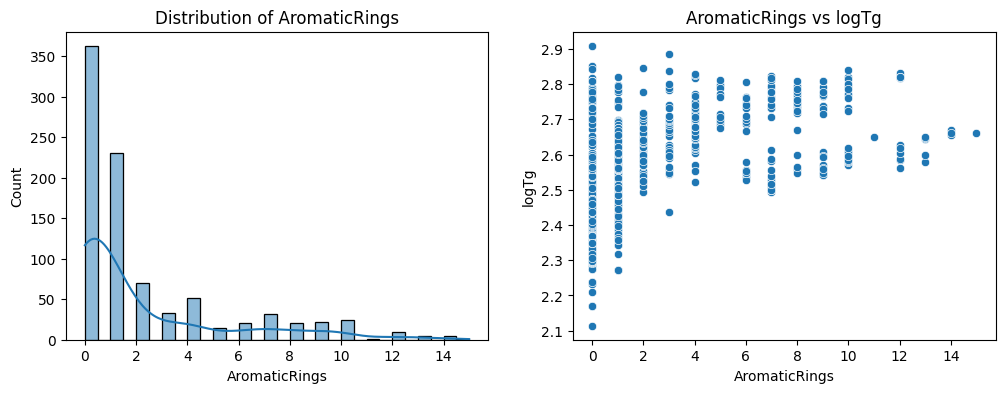

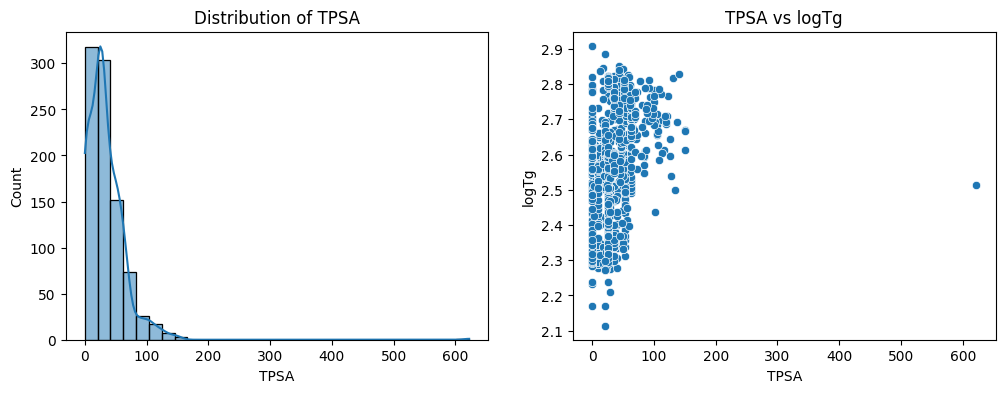

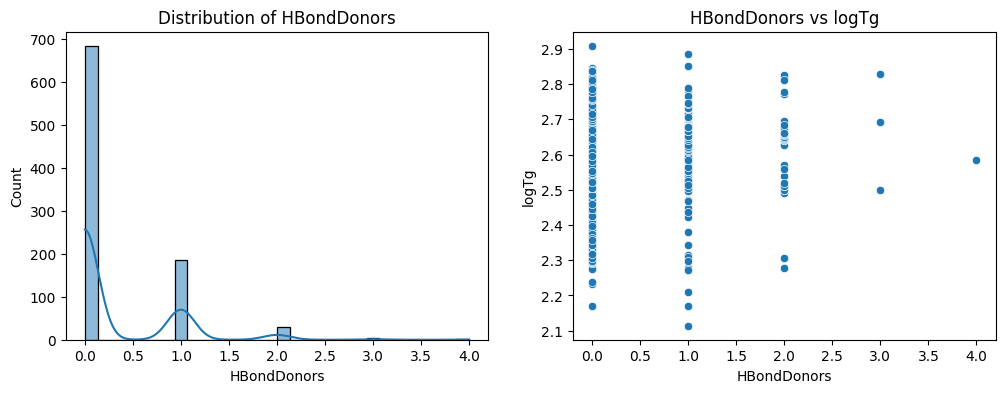

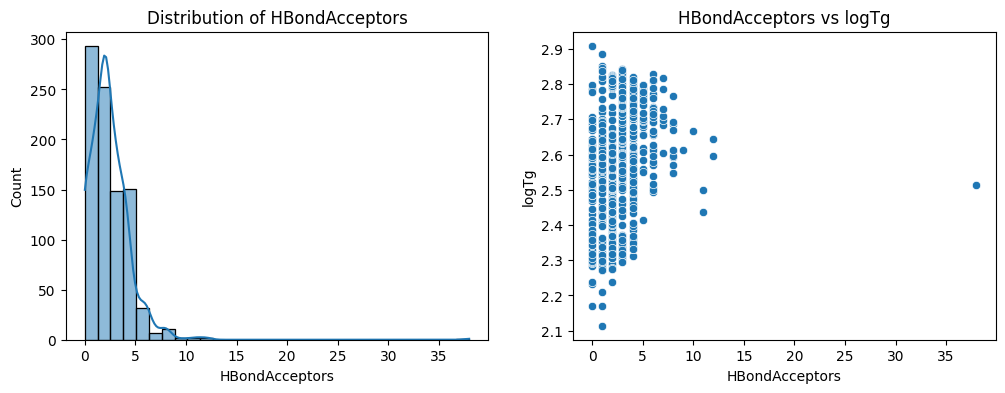

In [192]:
for feat_ in descriptor_list:
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df_input_w_features[feat_], bins=30, kde=True)
    plt.title(f'Distribution of {feat_}')
    plt.xlabel(feat_)
    plt.ylabel('Count')
    plt.subplot(1, 2, 2)
    sns.scatterplot(x=df_input_w_features[feat_], y=df_input_w_features['logTg'])
    plt.title(f'{feat_} vs logTg')
    plt.xlabel(feat_)
    plt.ylabel('logTg')
    plt.show()

# Prepping training data

In [193]:
train_df = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'data_902_original_15desc_logTg_train.csv')

In [194]:
train_df.shape

(683, 19)

In [195]:
train_df.head()

,No,Index,nCsp2,SpMax_EA(ri),SpMax_AEA(dm),SM11_EA,Eig03_EA,B03[C-N],S1K,piPC05,piPC07,AAC,SIC4,SpDiam_B(e),SpMax1_Bh(i),Mor31v,TE1,logTg,Series
0,1,PPD_007,1,1.568,3.150,8.507,-1.000,0,4.494,0.000,0.000,0.722,0.000,4.599,3.374,0.079,1.028,2.7077,T
1,2,PPD_008,1,2.352,3.621,8.507,-1.000,1,3.948,0.000,0.000,1.371,0.000,4.608,3.425,0.023,2.840,2.8520,T
2,3,PPD_010,2,2.446,4.150,10.289,0.821,1,8.896,2.565,2.197,1.096,1.000,4.766,3.443,0.161,5.075,2.8177,T
3,5,PPD_019,1,2.378,3.898,9.304,0.471,0,6.468,2.485,0.000,1.299,0.875,4.717,3.427,0.031,3.641,2.7552,T
4,6,PPD_029,1,2.379,3.779,9.306,1.887,0,18.221,3.045,2.944,0.426,0.726,4.656,3.383,1.177,10.695,2.7687,T


In [196]:
df_smiles_train = df_input_w_features[df_input_w_features['ID'].isin(train_df['Index'])].reset_index(drop=True)

In [197]:
df_smiles_train.shape

(683, 18)

In [198]:
train_smis = df_smiles_train.loc[:, smiles_column].values

In [199]:
train_smis.shape

(683,)

In [200]:
train_ys = df_smiles_train.loc[:, target_column].values

In [201]:
train_ys.shape

(683, 1)

In [202]:
train_smis[:5], train_ys[:5]

(array(['C=CC(=C)Cl', 'C=CC(N)=O', 'C=CC(=O)OCC(C#N)CC', 'C=CC(=O)OCC#N',
        'C=CC(=O)OCCCCCCCCCCCCCCCCCC'], dtype=object),
 array([[2.7077],
        [2.852 ],
        [2.8177],
        [2.7552],
        [2.7687]]))

In [203]:
train_mols = [utils.make_mol(smi, keep_h=False, add_h=False) for smi in train_smis]

In [204]:
feat_cols = descriptors_df.columns.tolist()
print(f"Feature columns: {feat_cols}")
train_V_fs = df_smiles_train.loc[:, feat_cols].values

Feature columns: ['MW', 'FreeVolumeProxy', 'RotatableBonds', 'AromaticRings', 'TPSA', 'HBondDonors', 'HBondAcceptors']


In [205]:
type(train_V_fs)

numpy.ndarray

In [206]:
train_V_fs.shape

(683, 7)

# Create the dataset
MoleculeDatapoints are made from target value(s) and SMILES. 

In [207]:
train_data = [
    data.MoleculeDatapoint(mol, y, x_d=X_d) for mol, y, X_d in zip(train_mols, train_ys, train_V_fs)
]

In [208]:
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()

In [209]:
train_dset = data.MoleculeDataset(train_data, featurizer)

In [210]:
scaler = train_dset.normalize_targets()

In [211]:
extra_datapoint_descriptors_scaler = train_dset.normalize_inputs("X_d")

In [212]:
train_loader = data.build_dataloader(train_dset, batch_size=64, num_workers=num_workers)

In [213]:
train_loader.batch_size

64

# Message-Passing Neural Network (MPNN)

In [214]:
# construct molecular graph using message passing to learn bond-level hidden representations
mp = nn.BondMessagePassing()

In [215]:
mp.output_dim

300

In [216]:
print(nn.agg.AggregationRegistry)

ClassRegistry {
    'mean': <class 'chemprop.nn.agg.MeanAggregation'>,
    'sum': <class 'chemprop.nn.agg.SumAggregation'>,
    'norm': <class 'chemprop.nn.agg.NormAggregation'>
}


In [217]:
#An Aggregation is responsible for constructing a graph-level representation from the set of node-level representations after message passing.
agg = nn.MeanAggregation()

In [218]:
print(nn.PredictorRegistry)

ClassRegistry {
    'regression': <class 'chemprop.nn.predictors.RegressionFFN'>,
    'regression-mve': <class 'chemprop.nn.predictors.MveFFN'>,
    'regression-evidential': <class 'chemprop.nn.predictors.EvidentialFFN'>,
    'regression-quantile': <class 'chemprop.nn.predictors.QuantileFFN'>,
    'classification': <class 'chemprop.nn.predictors.BinaryClassificationFFN'>,
    'classification-dirichlet': <class 'chemprop.nn.predictors.BinaryDirichletFFN'>,
    'multiclass': <class 'chemprop.nn.predictors.MulticlassClassificationFFN'>,
    'multiclass-dirichlet': <class 'chemprop.nn.predictors.MulticlassDirichletFFN'>,
    'spectral': <class 'chemprop.nn.predictors.SpectralFFN'>
}


In [219]:
# nn.UnscaleTransform.from_standard_scaler creates a transform that can be used to unscale model outputs
output_transform = nn.UnscaleTransform.from_standard_scaler(scaler)

In [220]:
ffn_input_dim = mp.output_dim + train_V_fs.shape[1]

In [221]:
ffn_input_dim

307

In [222]:
# Recreate the FFN using the authoritative input dimension computed above
ffn = nn.RegressionFFN(
    input_dim=ffn_input_dim,
    output_transform=output_transform,
)
print('FFN created with input_dim =', ffn.input_dim)

FFN created with input_dim = 307


In [223]:
ffn.criterion

MSE(task_weights=[[1.0]])

In [224]:
metric_list = [nn.metrics.R2Score(), nn.metrics.RMSE()] # Only the first metric is used for training and early stopping

In [225]:
batch_norm = True

In [231]:
X_d_transform = nn.ScaleTransform.from_standard_scaler(extra_datapoint_descriptors_scaler)

In [234]:
mpnn = models.MPNN(
    mp, agg, ffn, batch_norm, metric_list, X_d_transform=X_d_transform
)

In [235]:
mpnn

MPNN(
  (message_passing): BondMessagePassing(
    (W_i): Linear(in_features=86, out_features=300, bias=False)
    (W_h): Linear(in_features=300, out_features=300, bias=False)
    (W_o): Linear(in_features=372, out_features=300, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
    (tau): ReLU()
    (V_d_transform): Identity()
    (graph_transform): Identity()
  )
  (agg): MeanAggregation()
  (bn): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (predictor): RegressionFFN(
    (ffn): MLP(
      (0): Sequential(
        (0): Linear(in_features=307, out_features=300, bias=True)
      )
      (1): Sequential(
        (0): ReLU()
        (1): Dropout(p=0.0, inplace=False)
        (2): Linear(in_features=300, out_features=1, bias=True)
      )
    )
    (criterion): MSE(task_weights=[[1.0]])
    (output_transform): UnscaleTransform()
  )
  (X_d_transform): ScaleTransform()
  (metrics): ModuleList(
    (0): R2Score()
    (1): RMSE(task_weights=[[1.0]]

# Set up trainer

In [236]:
# Configure model checkpointing
checkpointing = ModelCheckpoint(
    dirpath="checkpoints",  # Directory where model checkpoints will be saved
    filename="best-{epoch}-{val_loss:.2f}",  # Filename format for checkpoints, including epoch and validation loss
    monitor="train_loss",  # Metric used to select the best checkpoint (based on validation loss)
    mode="min",  # Save the checkpoint with the lowest validation loss (minimization objective)
)

In [237]:
trainer = pl.Trainer(
   # deterministic=True,
    logger=False,
    enable_checkpointing=False, # Use `True` if you want to save model checkpoints. The checkpoints will be saved in the `checkpoints` folder.
    enable_progress_bar=True,
    accelerator="auto",
    devices=1, # 
    max_epochs=50, # number of epochs to train for
    #callbacks=[checkpointing], # Use the configured checkpoint callback
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [238]:
trainer.fit(mpnn, train_loader)

/home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.

  | Name            | Type               | Params | Mode 
---------------------------------------------------------------
0 | message_passing | BondMessagePassing | 227 K  | train
1 | agg             | MeanAggregation    | 0      | train
2 | bn              | BatchNorm1d        | 600    | train
3 | predictor       | RegressionFFN      | 92.7 K | train
4 | X_d_transform   | ScaleTransform     | 0      | train
5 | metrics         | ModuleList         | 0      | train
---------------------------------------------------------------
321 K     Trainable params
0         Non-trainable params
321 K     Total params
1.284     Tota

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


In [240]:
trainer.callback_metrics

{'train_loss': tensor(0.0648),
 'train_loss_step': tensor(0.0386),
 'train_loss_epoch': tensor(0.0648)}

In [241]:
from sklearn.metrics import r2_score, root_mean_squared_error

In [242]:
train_loader_for_preds = data.build_dataloader(train_dset, num_workers=num_workers, shuffle=False) 

In [243]:
train_preds = trainer.predict(mpnn, train_loader_for_preds)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [244]:
df_smiles_train['logTg'].shape

(683,)

In [245]:
train_preds = np.concatenate(train_preds, axis=0)

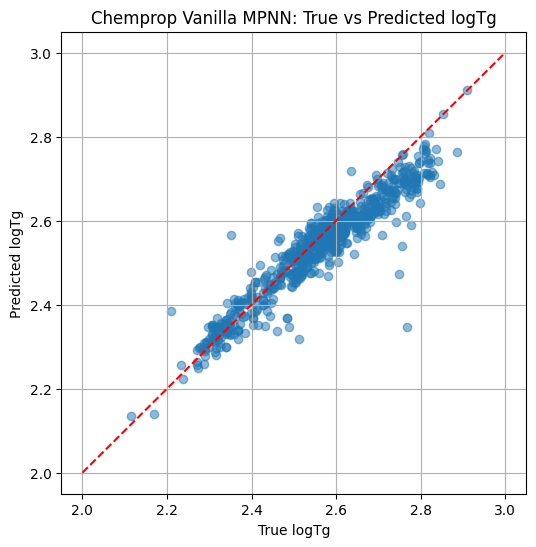

In [246]:
plt.figure(figsize=(6,6))
plt.scatter(df_smiles_train['logTg'], train_preds, alpha=0.5)
plt.plot([2,3], [2,3], color='red', linestyle='--')
plt.xlabel('True logTg')
plt.ylabel('Predicted logTg')
plt.title('Chemprop Vanilla MPNN: True vs Predicted logTg')
plt.grid(True)
plt.show()

In [247]:
# Calculate R² and RMSE
r2 = r2_score(df_smiles_train['logTg'], train_preds)
rmse = root_mean_squared_error(df_smiles_train['logTg'], train_preds)
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: 0.8574
RMSE: 0.0540


# Testing model prediction

In [255]:
df_smiles_test = df_input_w_features[~df_input_w_features['ID'].isin(train_df['Index'])].reset_index(drop=True)

In [256]:
df_smiles_test.shape

(219, 18)

In [257]:
test_smis = df_smiles_test[smiles_column]

In [258]:
test_smis[:5]

0    C=CC(=O)OCC(F)(F)C(F)F
1               C=CC(C)(C)C
2      C=C(CC(=O)OC)C(=O)OC
3                C=CC(=O)CC
4                    C=CSCC
Name: SMILES_clean, dtype: object

In [259]:
test_mols = [utils.make_mol(smi, keep_h=False, add_h=False) for smi in test_smis]

In [260]:
test_V_fs = df_smiles_test.loc[:, feat_cols].values

In [ ]:
type(test_V_fs)

numpy.ndarray

In [ ]:
test_V_fs.shape

(683, 7)

In [264]:
test_data = [
    data.MoleculeDatapoint(mol, x_d=X_d) for mol, X_d in zip(test_mols, test_V_fs)
]

In [265]:
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
test_dset = data.MoleculeDataset(test_data, featurizer)

test_loader = data.build_dataloader(test_dset, shuffle=False)

In [266]:
test_preds = trainer.predict(mpnn, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

In [267]:
test_preds = np.concatenate(test_preds, axis=0)
df_smiles_test['pred'] = test_preds

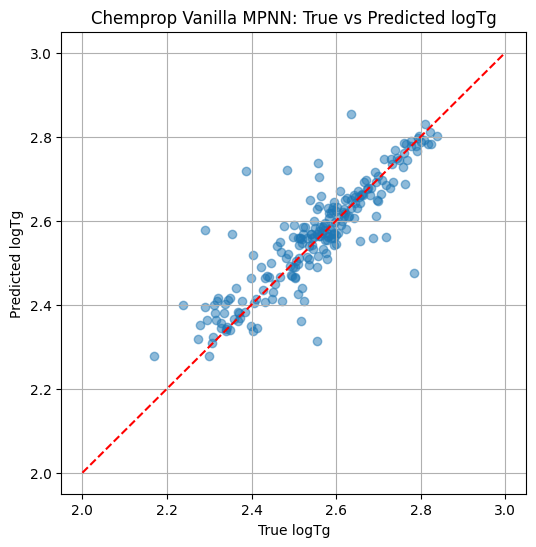

In [268]:
plt.figure(figsize=(6,6))
plt.scatter(df_smiles_test['logTg'], df_smiles_test['pred'], alpha=0.5)
plt.plot([2,3], [2,3], color='red', linestyle='--')
plt.xlabel('True logTg')
plt.ylabel('Predicted logTg')
plt.title('Chemprop Vanilla MPNN: True vs Predicted logTg')
plt.grid(True)
plt.show()

In [269]:
# Calculate R² and RMSE
r2 = r2_score(df_smiles_test['logTg'], df_smiles_test['pred'])
rmse = root_mean_squared_error(df_smiles_test['logTg'], df_smiles_test['pred'])
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: 0.7601
RMSE: 0.0680


In [270]:
# Save the trained model
save_model(PROJECT_ROOT / 'data' / 'processed' /'chemprop_w_features_mpnn_model.pickle', mpnn)

---